In [29]:
import os
import json
import numpy as np
import librosa

In [30]:
# Define Correct Paths
BASE_PATH = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all"

AUDIO_PATH = os.path.join(BASE_PATH, "audio")
JSON_PATH = os.path.join(BASE_PATH, "examples-train-original.json")

print("Audio Path Exists:", os.path.exists(AUDIO_PATH))
print("JSON Path Exists:", os.path.exists(JSON_PATH))

Audio Path Exists: True
JSON Path Exists: True


In [31]:
#Load JSON Metadata
with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Total samples in JSON:", len(metadata))

Total samples in JSON: 289205


In [32]:
# Select Few Instruments

# selected_families = ["keyboard", "guitar", "bass", "string"]

# filtered_files = []

# for file_id, info in metadata.items():
#     if info["instrument_family_str"] in selected_families:
#         filtered_files.append((file_id, info["instrument_family_str"]))

# print("Filtered samples:", len(filtered_files))


# # # Create label mapping
# # selected_families = ["keyboard", "guitar", "bass", "string"]

# # label_map = {name: idx for idx, name in enumerate(selected_families)}

# # print(label_map)

# selected_families = ["keyboard", "guitar", "bass", "string"]

# label_map = {name: idx for idx, name in enumerate(selected_families)}

# print(label_map)


# Select Few Instruments
selected_families = ["keyboard", "guitar", "bass", "string", "brass", "reed"]

filtered_files = []

for file_id, info in metadata.items():
    if info["instrument_family_str"] in selected_families:
        filtered_files.append((file_id, info["instrument_family_str"]))

print("Filtered samples:", len(filtered_files))

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print(label_map)

Filtered samples: 196045
{'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3, 'brass': 4, 'reed': 5}


In [33]:
# Load One Audio File
file_id, label = filtered_files[100]

file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

audio, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)
print("Audio Shape:", audio.shape)
print("Label:", label)

Sampling Rate: 16000
Audio Shape: (64000,)
Label: keyboard


In [34]:
# Trim Silence
audio_trimmed, _ = librosa.effects.trim(audio)

print("Original length:", len(audio))
print("Trimmed length:", len(audio_trimmed))

Original length: 64000
Trimmed length: 50176


In [35]:
# RMS Normalization
def rms_normalize(signal, target_rms=0.1):
    rms = np.sqrt(np.mean(signal**2))
    return signal * (target_rms / rms)

audio_normalized = rms_normalize(audio_trimmed)

# Check new RMS
new_rms = np.sqrt(np.mean(audio_normalized**2))
print("New RMS:", new_rms)

New RMS: 0.10000001


In [36]:
# Convert Audio → Mel-Spectrogram

import matplotlib.pyplot as plt
import librosa.display

mel_spec = librosa.feature.melspectrogram(
    y=audio_normalized,
    sr=sr,
    n_mels=128
)

print("Mel Spectrogram Shape:", mel_spec.shape)


Mel Spectrogram Shape: (128, 99)


In [37]:
# Apply Log Scaling (Convert to dB)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("After Log Scaling Shape:", mel_spec_db.shape)

After Log Scaling Shape: (128, 99)


In [38]:
# Feature Standardization

mean = np.mean(mel_spec_db)
std = np.std(mel_spec_db)

mel_spec_std = (mel_spec_db - mean) / std

print("New Mean:", np.mean(mel_spec_std))
print("New Std:", np.std(mel_spec_std))

New Mean: -2.8417568e-07
New Std: 0.99999994


In [39]:
import random

num_classes = len(selected_families)

X = []
Y = []

fixed_length = 128

for file_id, label in filtered_files[:20000]:

    # choose number of instruments
    num_mix = random.choice([1,2,3,4])

    labels = [label]

    audio_list = []

    # load first instrument
    file_path = os.path.join(AUDIO_PATH, file_id + ".wav")
    audio, sr = librosa.load(file_path, sr=16000)
    audio, _ = librosa.effects.trim(audio)
    audio = rms_normalize(audio)

    audio_list.append(audio)

    # load additional instruments
    for i in range(num_mix-1):

        file2, label2 = random.choice(filtered_files)

        file2_path = os.path.join(AUDIO_PATH, file2 + ".wav")

        audio2, _ = librosa.load(file2_path, sr=16000)
        audio2, _ = librosa.effects.trim(audio2)

        audio2 = rms_normalize(audio2)

        audio_list.append(audio2)
        labels.append(label2)

    # make all audios same length
    min_len = min(len(a) for a in audio_list)

    audio_list = [a[:min_len] for a in audio_list]

    # mix audios
    mixed_audio = np.zeros(min_len)

    weight = 1 / len(audio_list)

    for a in audio_list:
        mixed_audio += weight * a

    audio = mixed_audio

    # -------- MEL SPECTROGRAM --------

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    # mel_db = librosa.power_to_db(mel, ref=np.max)
    # mel_db = mel_db / 80.0
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

    # -------- FIX SIZE --------

    if mel_db.shape[1] < fixed_length:
        pad_width = fixed_length - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :fixed_length]

    X.append(mel_db)

    # -------- MULTI HOT LABEL --------

    multi_label = np.zeros(num_classes)

    for l in labels:
        multi_label[label_map[l]] = 1

    Y.append(multi_label)

print("Processed samples:", len(X))

Processed samples: 20000


In [40]:
# Convert Labels to Numbers

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print("Label Map:", label_map)

Label Map: {'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3, 'brass': 4, 'reed': 5}


In [41]:
X = np.array(X)
Y = np.array(Y)

X = X[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (20000, 128, 128, 1)
Y shape: (20000, 6)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp,
    test_size=0.5,
    random_state=42,
    stratify=Y_temp
)


# Compute mean and std ONLY from training set
train_mean = np.mean(X_train)
train_std = np.std(X_train)

# Apply same normalization to all sets
# X_train = (X_train - train_mean) / train_std
# X_val   = (X_val - train_mean) / train_std
# X_test  = (X_test - train_mean) / train_std

# print("Normalization Done Properly")



print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (16000, 128, 128, 1)
Validation: (2000, 128, 128, 1)
Test: (2000, 128, 128, 1)


In [43]:
# import matplotlib.pyplot as plt
# import librosa.display

# plt.figure(figsize=(6, 4))
# librosa.display.specshow(X_train[50].squeeze(), 
#                          sr=16000, 
#                          x_axis='time', 
#                          y_axis='mel')

# plt.colorbar(format='%+2.0f dB')
# plt.title("Mel Spectrogram")
# plt.show()

In [44]:
# import librosa
# import librosa.display
# import matplotlib.pyplot as plt
# import os

# # Choose audio index
# index = 10   # change this to view different audio

# file_id, label = filtered_files[index]
# file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

# # Load audio directly
# audio, sr = librosa.load(file_path, sr=16000)

# # Generate MFCC
# mfcc = librosa.feature.mfcc(
#     y=audio,
#     sr=sr,
#     n_mfcc=13
# )

# print("File:", file_id)
# print("Label:", label)
# print("MFCC Shape:", mfcc.shape)

# # Display MFCC
# plt.figure(figsize=(6,4))
# librosa.display.specshow(mfcc,
#                          sr=sr,
#                          x_axis='time')
# plt.colorbar()
# plt.title(f"MFCC - {label}")
# plt.show()

In [45]:
# # Choose Audio

# index = 50  # I can choose any index

# file_id, label = filtered_files[index]
# file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

# audio, sr = librosa.load(file_path, sr=16000)

# print("File:", file_id)
# print("Label:", label)

In [46]:
# # Show Original Waveform

# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,3))
# plt.plot(audio)
# plt.title("Original Waveform")
# plt.show()

In [47]:
# Applied two Augmentation...

# #Pitch shifting
# audio_pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=1)


# # Adding background noise
# noise = 0.005 * np.random.randn(len(audio))
# audio_noise = audio + noise


import random
import numpy as np

def augment_sample(mel_spec):
    
    # Add stronger noise
    if random.random() < 0.5:
        noise = np.random.normal(0, 0.03, mel_spec.shape)
        mel_spec = mel_spec + noise

    # Time shift
    if random.random() < 0.5:
        shift = random.randint(-20, 20)
        mel_spec = np.roll(mel_spec, shift, axis=1)

    # Time masking
    if random.random() < 0.5:
        t = random.randint(10, 25)
        t0 = random.randint(0, mel_spec.shape[1] - t)
        mel_spec[:, t0:t0+t] = 0

    # Frequency masking
    if random.random() < 0.5:
        f = random.randint(5, 15)
        f0 = random.randint(0, mel_spec.shape[0] - f)
        mel_spec[f0:f0+f, :] = 0

    return mel_spec


augmented_X = []
augmented_Y = []

for i in range(len(X_train)):
    mel = X_train[i]
    label = Y_train[i]

    # original
    augmented_X.append(mel)
    augmented_Y.append(label)

    # augmented
    mel_aug = augment_sample(mel.copy())
    augmented_X.append(mel_aug)
    augmented_Y.append(label)

X_train = np.array(augmented_X)
Y_train = np.array(augmented_Y)

print("New X_train shape:", X_train.shape)

New X_train shape: (32000, 128, 128, 1)


In [48]:
# # Showing Augmented Waveforms

# plt.figure(figsize=(10,3))
# plt.plot(audio_pitch)
# plt.title("Pitch Shifted Waveform")
# plt.show()

# plt.figure(figsize=(10,3))
# plt.plot(audio_noise)
# plt.title("Noise Added Waveform")
# plt.show()

In [49]:
# # Generate Spectrograms of Augmented Waveforms

# def plot_mel(audio_signal, title):
#     mel = librosa.feature.melspectrogram(
#         y=audio,
#         sr=sr,
#         n_mels=128,
#         n_fft=2048,
#         hop_length=512
#     )
#     mel_db = librosa.power_to_db(mel, ref=np.max)

#     plt.figure(figsize=(6,4))
#     librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
#     plt.colorbar()
#     plt.title(title)
#     plt.show()

In [50]:
# plot_mel(audio, "Original Mel Spectrogram")
# plot_mel(audio_pitch, "Pitch Shifted Mel Spectrogram")
# plot_mel(audio_noise, "Noise Added Mel Spectrogram")

## My observation

After applying pitch shifting, the harmonic structure in the spectrogram shifted slightly upward in frequency while maintaining the overall timbre pattern.

After adding background noise, the waveform showed small fluctuations and the spectrogram displayed mild background energy increase.

Overall, the augmentation techniques introduced controlled variations without altering the fundamental identity of the instrument, thereby enhancing data diversity while maintaining label consistency.

In [51]:
# Apply same normalization to all sets
X_train = (X_train - train_mean) / train_std
X_val   = (X_val - train_mean) / train_std
X_test  = (X_test - train_mean) / train_std

print("Normalization Done Properly")

Normalization Done Properly


In [52]:
num_classes = Y_train.shape[1]
print("Number of classes:", num_classes)


# Training structure...

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1), kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='sigmoid'))

# Using Adam Optimizer------------------------------------
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



# Using SGD optimizer ------------------------------------
# from tensorflow.keras.optimizers import SGD

# model.compile(
#     optimizer=SGD(learning_rate=0.01, momentum=0.9),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )



# Using RMSprop optimizer -------------------------------
# from tensorflow.keras.optimizers import RMSprop

# model.compile(
#     optimizer=RMSprop(learning_rate=0.0003),
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )



model.summary()

Number of classes: 6


2026-03-14 18:21:19.545463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773512479.951866      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773512480.071930      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773512481.062404      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773512481.062433      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773512481.062436      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,094 (1.74 MB)

 Trainable params: 456,134 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [53]:
# Used Callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=3, factor=0.3)


# Train the model...

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


I0000 00:00:1773512510.037701     149 service.cc:152] XLA service 0x7a88f00084d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773512510.037733     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773512510.037737     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773512510.788191     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-14 18:21:53.428711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-14 18:21:53.576750: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   5/1000 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.1456 - loss: 0.8300 

I0000 00:00:1773512517.109572     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.3275 - loss: 0.6597 - val_accuracy: 0.3560 - val_loss: 0.5281 - learning_rate: 3.0000e-04
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.3863 - loss: 0.5257 - val_accuracy: 0.3980 - val_loss: 0.4840 - learning_rate: 3.0000e-04
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4051 - loss: 0.4813 - val_accuracy: 0.3835 - val_loss: 0.4570 - learning_rate: 3.0000e-04
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4285 - loss: 0.4503 - val_accuracy: 0.3995 - val_loss: 0.4529 - learning_rate: 3.0000e-04
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4394 - loss: 0.4288 - val_accuracy: 0.4670 - val_loss: 0.4550 - learning_rate: 3.0000e-04
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.4445 - loss: 0.4100 - val_accuracy: 0.3995 - val_loss: 0.4221 - learning_rate: 3.0000e-04
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/

In [54]:
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4365 - loss: 0.4068
Test Accuracy: 0.44350001215934753
Test Loss: 0.408344566822052


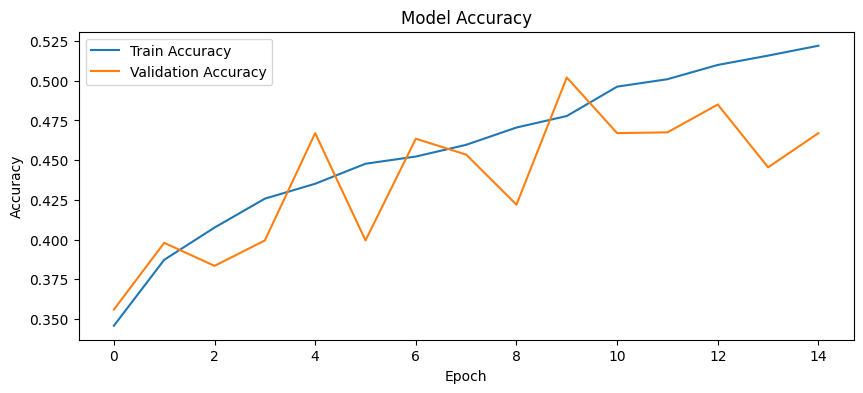

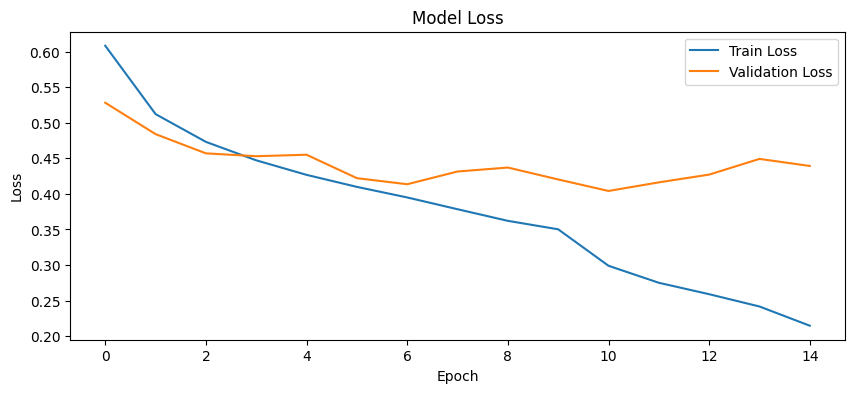

In [55]:
import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Loss Curve
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
# Get Predictions
Y_pred = model.predict(X_test)

# ⃣Apply Threshold (Very Important)
threshold = 0.5
Y_pred_binary = (Y_pred >= threshold).astype(int)

# Now shapes

print("Y_test shape:", Y_test.shape)
print("Y_pred_binary shape:", Y_pred_binary.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Y_test shape: (2000, 6)
Y_pred_binary shape: (2000, 6)


In [57]:
from sklearn.metrics import classification_report

print(classification_report(
    Y_test,
    Y_pred_binary,
    target_names=selected_families
))

              precision    recall  f1-score   support

    keyboard       0.73      0.71      0.72      1022
      guitar       0.67      0.64      0.65       699
        bass       0.80      0.81      0.81      1200
      string       0.84      0.74      0.79       448
       brass       0.80      0.67      0.73       303
        reed       0.74      0.60      0.66       330

   micro avg       0.76      0.72      0.74      4002
   macro avg       0.76      0.69      0.73      4002
weighted avg       0.76      0.72      0.74      4002
 samples avg       0.79      0.75      0.75      4002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


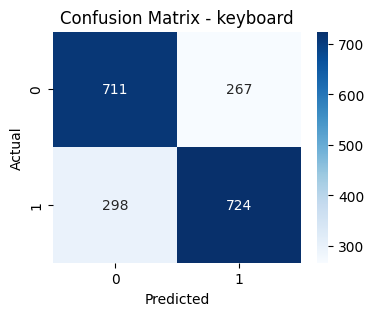

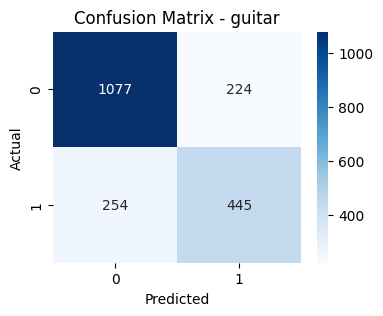

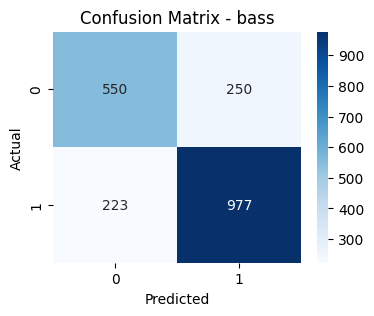

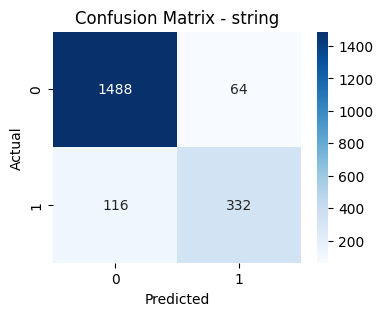

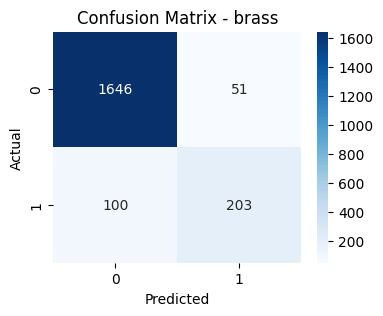

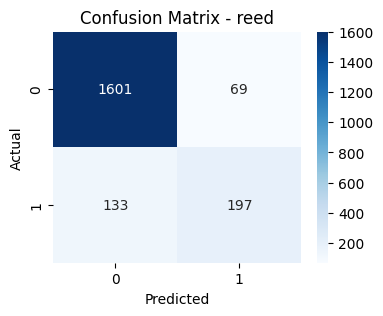

In [58]:
# Multilabel Confusion Matrix

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

mcm = multilabel_confusion_matrix(Y_test, Y_pred_binary)

for i, matrix in enumerate(mcm):
    plt.figure(figsize=(4,3))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {selected_families[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [59]:
def predict_audio(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    audio, _ = librosa.effects.trim(audio)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    # mel_db = librosa.power_to_db(mel, ref=np.max)
    # mel_db = mel_db / 80.0
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

    fixed_length = 128
    if mel_db.shape[1] < fixed_length:
        pad = fixed_length - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)))
    else:
        mel_db = mel_db[:,:fixed_length]

    mel_db = mel_db[..., np.newaxis]
    mel_db = (mel_db - train_mean) / train_std
    mel_db = np.expand_dims(mel_db, axis=0)

    prediction = model.predict(mel_db)[0]

    threshold = 0.35

    predicted_labels = [
        selected_families[i]
        for i in range(len(selected_families))
        if prediction[i] >= threshold
    ]

    print("Predicted instruments:", predicted_labels)
    print("Probabilities:", prediction)

In [60]:
# Pick Two Files

file1 = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all/audio/bass_acoustic_000-026-025.wav"
file2 = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all/audio/guitar_acoustic_000-024-100.wav"
file3 = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all/audio/keyboard_acoustic_000-021-025.wav"

# Mix Them
audio1, sr = librosa.load(file1, sr=16000)
audio2, sr = librosa.load(file2, sr=16000)
audio3, sr = librosa.load(file3, sr=16000)


# Make same length
# min_len = min(len(audio1), len(audio2))
min_len = min(len(audio1), len(audio2), len(audio3))

audio1 = audio1[:min_len]
audio2 = audio2[:min_len]
audio3 = audio3[:min_len]

# mixed_audio = audio1 + audio2
mixed_audio = 0.33*audio1 + 0.33*audio2 + 0.33*audio3


# Modify predict function to accept raw audio
def predict_mixed_audio(audio, sr=16000):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        n_fft=2048,
        hop_length=512
    )

    # mel_db = librosa.power_to_db(mel, ref=np.max)
    # mel_db = mel_db / 80.0
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-6)

    
    fixed_length = 128
    if mel_db.shape[1] < fixed_length:
        pad = fixed_length - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)))
    else:
        mel_db = mel_db[:,:fixed_length]

    mel_db = mel_db[..., np.newaxis]
    mel_db = (mel_db - train_mean) / train_std
    mel_db = np.expand_dims(mel_db, axis=0)

    prediction = model.predict(mel_db)[0]

    threshold = 0.25

    predicted = [
        selected_families[i]
        for i in range(len(selected_families))
        if prediction[i] >= threshold
    ]

    print("Predicted instruments:", predicted)
    print("Probabilities:", prediction)

# Test Mixed Audio
predict_mixed_audio(mixed_audio)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
Predicted instruments: ['keyboard', 'guitar']
Probabilities: [8.0215979e-01 6.0016364e-01 3.4115806e-02 8.2002347e-04 7.6544838e-04
 2.4408253e-03]


In [61]:
# import os

# audio_path = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all/audio/"
# files = os.listdir(audio_path)

# def get_files_by_family(family, n=3):
#     selected = [f for f in files if f.startswith(family)]
#     return selected[:n]

# print("Bass files:", get_files_by_family("bass"))
# print("Guitar files:", get_files_by_family("guitar"))
# print("Keyboard files:", get_files_by_family("keyboard"))
# print("String files:", get_files_by_family("string"))
# print("Brass files:", get_files_by_family("brass"))
# print("Reed files:", get_files_by_family("reed"))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


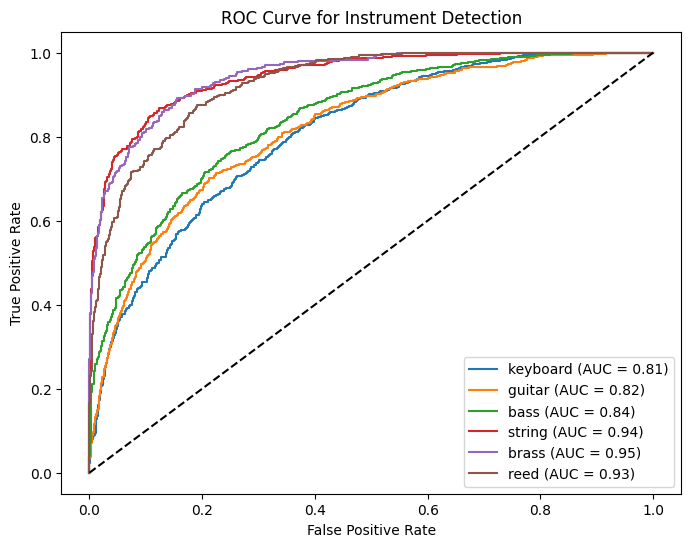

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Model predictions
Y_pred = model.predict(X_test)


# Plot ROC for each instrument
plt.figure(figsize=(8,6))

for i in range(num_classes):
    
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{selected_families[i]} (AUC = {roc_auc:.2f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Instrument Detection")
plt.legend()
plt.show()

In [64]:
test_loss, test_acc = model.evaluate(X_test, Y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


Y_pred = model.predict(X_test)

threshold = 0.3
Y_pred_binary = (Y_pred >= threshold).astype(int)


from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_binary, target_names=selected_families))


for i in range(5):
    print("Actual:", Y_test[i])
    print("Predicted:", Y_pred_binary[i])
    print("Probabilities:", Y_pred[i])
    print("------")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4365 - loss: 0.4068
Test Accuracy: 0.44350001215934753
Test Loss: 0.408344566822052
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

    keyboard       0.67      0.86      0.75      1022
      guitar       0.56      0.80      0.66       699
        bass       0.75      0.91      0.82      1200
      string       0.76      0.79      0.77       448
       brass       0.67      0.75      0.71       303
        reed       0.65      0.71      0.68       330

   micro avg       0.68      0.83      0.75      4002
   macro avg       0.68      0.80      0.73      4002
weighted avg       0.68      0.83      0.75      4002
 samples avg       0.72      0.85      0.76      4002

Actual: [1. 1. 1. 0. 0. 0.]
Predicted: [0 1 1 0 0 0]
Probabilities: [1.4458272e-01 4.7182760e-01 9.9949086e-01 8.7940411e-05 6.9992871e-05
 3.6983495e-04]
------
Actual: [1. 0. 1. 0. 0. 0.]
Predicted: [1 1 1 0 0 0]
Probabilitie

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## work done

I have added dropout layer(0 5) after fully conneded layer, Add l2 regulanzation to conv/dense layers. then Train model again.

Also Check dataset split, verify class distibution, inspect val samples, evaluate madel on val dataset